In [2]:
import pandas as pd
df = pd.read_csv('train.csv')
df_original = pd.read_csv('train.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


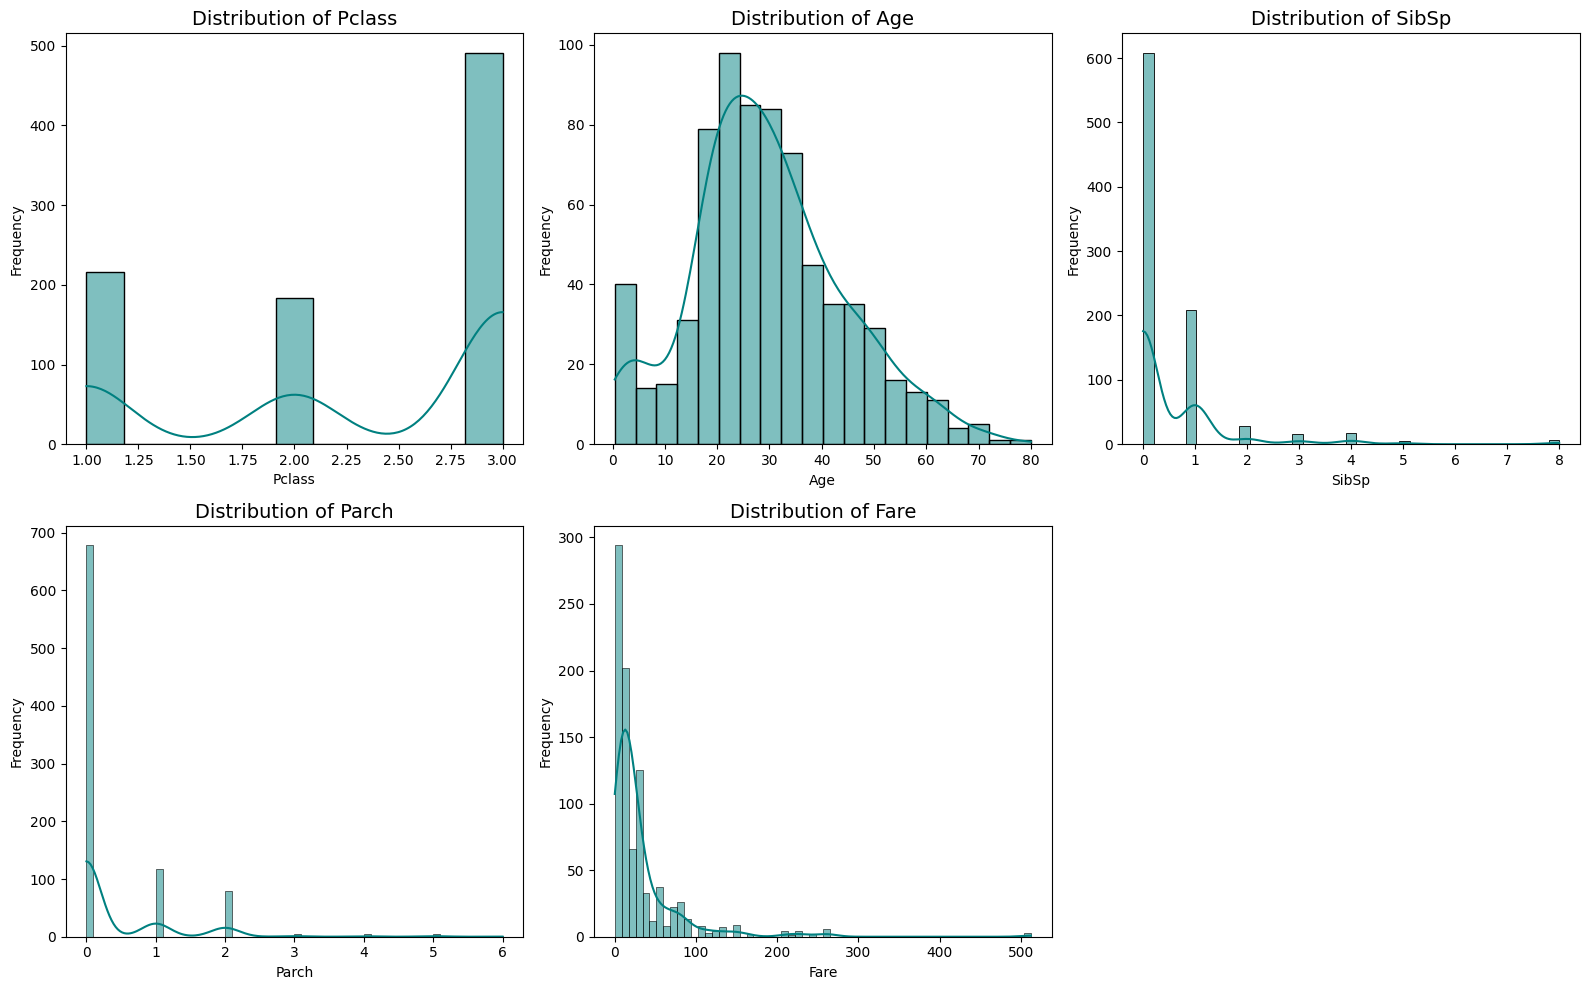

In [3]:
# Exercise 1: Data Scaling and Normalization
# Instructions

#     Identify numerical columns in the dataset like ‘Fare’ and ‘Age’.
##Numerical columns: Pclass, Age, SibSp, Parch, Fare

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the columns you want to plot
cols_to_plot = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

# 2. Create a grid of subplots (2 rows, 3 columns to fit all 5 plots)
# Note: we use plt.subplots() to manage the layout efficiently
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axes = axes.flatten() # Flatten the 2D array of axes into 1D for easy iteration

# 3. Iterate through columns and create a plot for each
for i, col in enumerate(cols_to_plot):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# 4. Hide the 6th (empty) subplot
axes[-1].axis('off')

# 5. Adjust layout to prevent label overlapping
plt.tight_layout()
plt.show()


In [4]:
#     Apply standardization (Z-score scaling) to features with a Gaussian distribution.
#Only Age has a gaussian distribution.
from sklearn.preprocessing import StandardScaler

# 1. Initialize the StandardScaler
scaler = StandardScaler()

# 2. Fit and Transform the 'Age' column
# Use double brackets [['Age']] to provide a 2D array as required by the scaler
df['Age_Scaled'] = scaler.fit_transform(df[['Age']])

# 3. View the results
print(df[['Age', 'Age_Scaled']].head())



    Age  Age_Scaled
0  22.0   -0.530377
1  38.0    0.571831
2  26.0   -0.254825
3  35.0    0.365167
4  35.0    0.365167


In [5]:

#     Apply Min-Max normalization to features that require bounded ranges.

#     Analyze the effect of scaling and normalization on model performance.

# Hint: Use StandardScaler and MinMaxScaler from scikit-learn.
from sklearn.preprocessing import MinMaxScaler

# 1. Select numeric features that we want to normalize
features_to_scale = ['Pclass', 'Age', 'Fare', 'SibSp', 'Parch']

# 2. Initialize the MinMaxScaler (default range is [0, 1])
mm_scaler = MinMaxScaler()

# 3. Fit and Transform the selected features
# We apply the transformation directly to those columns
df[features_to_scale] = mm_scaler.fit_transform(df[features_to_scale])

# 4. Verify that the Min is 0 and the Max is 1 for all columns
print(df[features_to_scale].agg(['min', 'max']))

     Pclass  Age  Fare  SibSp  Parch
min     0.0  0.0   0.0    0.0    0.0
max     1.0  1.0   1.0    1.0    1.0


In [10]:
# Exercise 2: Creating Composite Features
# Instructions

#     Create a new feature, ‘Family Size’, by combining ‘SibSp’ (siblings and spouses) and ‘Parch’ (parents and children).
df2 = df_original.copy()
df2['Family Size'] = df2['SibSp'] + df2['Parch'] + 1

#     Create a ‘IsAlone’ feature to indicate whether a passenger is traveling alone.
df2['IsAlone'] = (df2['Family Size'] == 1)
df2.head()




,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family Size,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,False
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,True


In [12]:
#     Explore the relationship between these new features and the survival rate.
df2.groupby('Family Size')['Survived'].mean()
# Hint: Use basic arithmetic operations and conditional statements in Pandas.


Family Size
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

In [13]:
df2.groupby('IsAlone')['Survived'].mean()

IsAlone
False    0.505650
True     0.303538
Name: Survived, dtype: float64

In [25]:
# Exercise 3: Data Normalization on the Titanic Dataset
# Instructions

#     Import the titanic dataset using Pandas in Python.
#     Apply Min-Max normalization and Z-score normalization to these columns : Age and Fare
features_to_scale = ['Age', 'Fare']

# 2. Initialize the MinMaxScaler (default range is [0, 1])
mm_scaler = MinMaxScaler()

# 3. Fit and Transform the selected features
# We apply the transformation directly to those columns
df2[['Age_MinMax','Fare_MinMax']] = mm_scaler.fit_transform(df[features_to_scale])
df2
from sklearn.preprocessing import StandardScaler

# 1. Initialize the StandardScaler
scaler = StandardScaler()

# 2. Select the columns and apply the transformation
# We use double brackets [['Age', 'Fare']] to pass them as a DataFrame
df2[['Age_ZScaled', 'Fare_ZScaled']] = scaler.fit_transform(df2[['Age', 'Fare']])

# 3. Verify the results (Mean should be ~0, Std Dev should be ~1)
print(df2[['Age_ZScaled', 'Fare_ZScaled']].describe().round(2))

       Age_ZScaled  Fare_ZScaled
count       714.00        891.00
mean          0.00          0.00
std           1.00          1.00
min          -2.02         -0.65
25%          -0.66         -0.49
50%          -0.12         -0.36
75%           0.57         -0.02
max           3.47          9.67


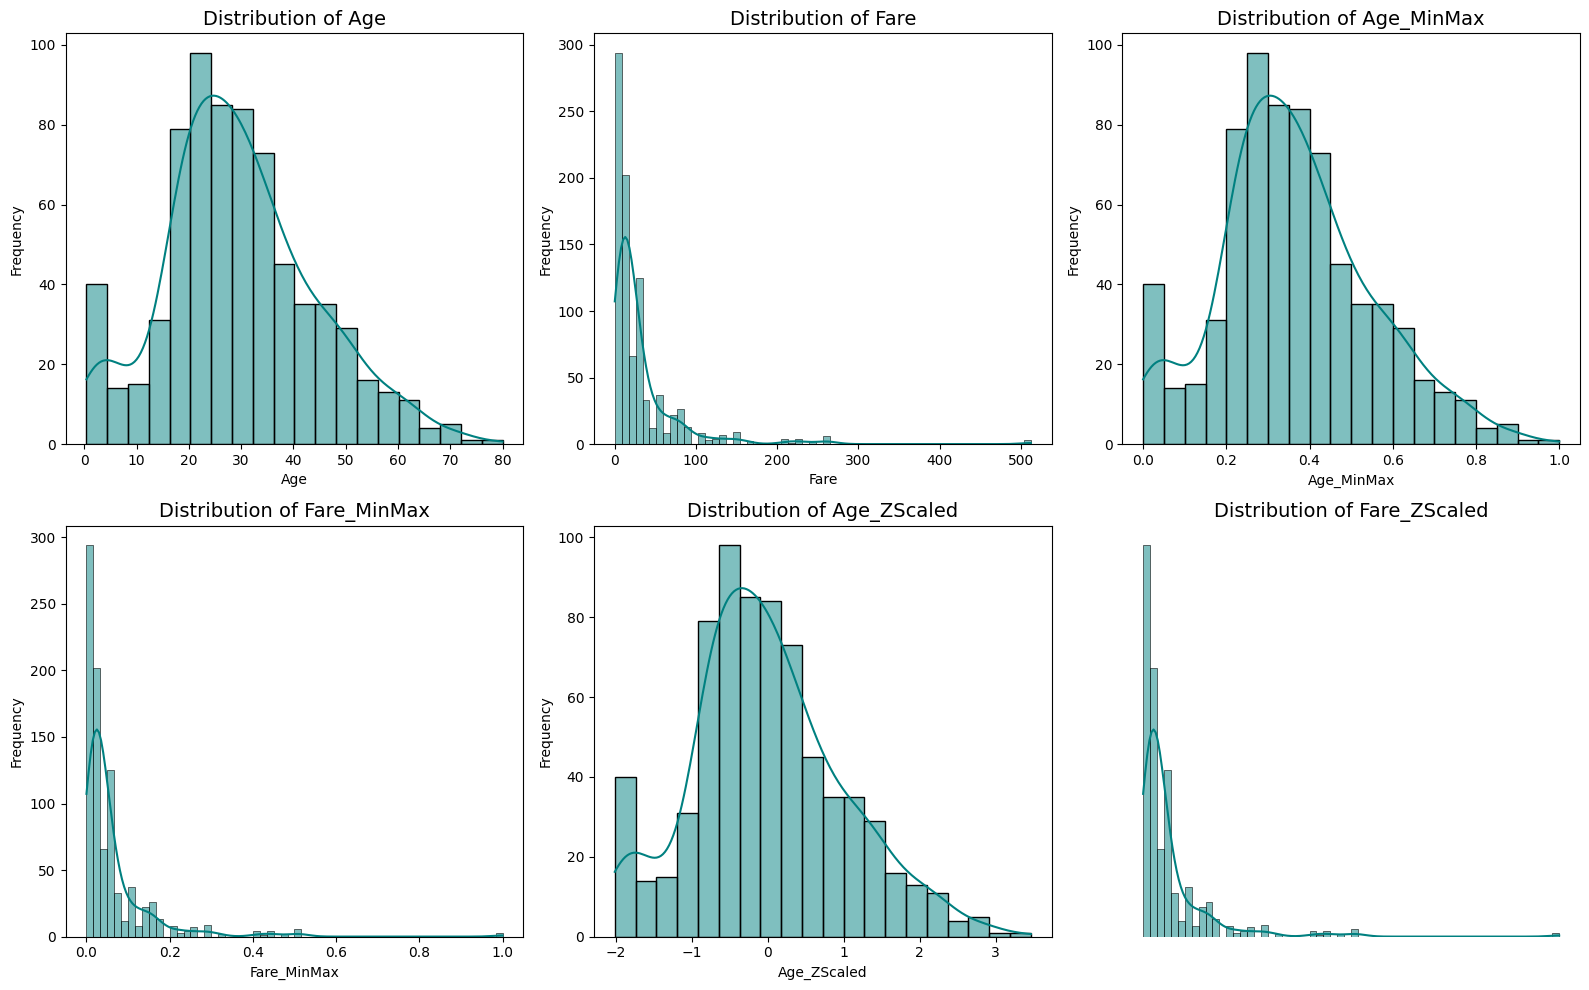

In [29]:
# 1. Define the columns you want to plot
cols_to_plot = ['Age', 'Fare', 'Age_MinMax','Fare_MinMax','Age_ZScaled','Fare_ZScaled']
# 2. Create a grid of subplots (2 rows, 3 columns to fit all 5 plots)
# Note: we use plt.subplots() to manage the layout efficiently
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axes = axes.flatten() # Flatten the 2D array of axes into 1D for easy iteration

# 3. Iterate through columns and create a plot for each
for i, col in enumerate(cols_to_plot):
    sns.histplot(df2[col], kde=True, ax=axes[i], color='teal', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# 4. Hide the 6th (empty) subplot
axes[-1].axis('off')

# 5. Adjust layout to prevent label overlapping
plt.tight_layout()
plt.show()


In [41]:
#Conclusion: Distributions look the same before and after normalization, and that is the point.

In [42]:
# Exercise 4 : Data Reduction and Aggregation
# Instructions

#     Perform data reduction on the titanic dataset by implementing dimensionality reduction techniques like Principal Component Analysis (PCA).
df3 = df2.copy()

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Prepare Features (Handling categories and missing values)
df_encoded = pd.get_dummies(df3[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']], drop_first=True)
df_encoded['Age'] = df_encoded['Age'].fillna(df_encoded['Age'].median())

# 2. Standardize the data (Mandatory for PCA)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_encoded)

# 3. Apply PCA (Reducing to 2 dimensions)
pca = PCA(n_components=2)
pca_results = pca.fit_transform(scaled_data)

# 4. Save to a new DataFrame
pca_df = pd.DataFrame(data=pca_results, columns=['PC1', 'PC2'])
pca_df['Survived'] = df3['Survived']
pca_df

,PC1,PC2,Survived
0,-1.060766,-0.652982,0
1,1.887126,1.094850,1
2,-0.561333,-0.391072,1
3,1.533719,0.630031,1
4,-1.181506,0.339088,0
...,...,...,...
886,-0.569923,0.529027,0
887,0.883867,0.385117,1
888,0.786667,-1.898649,0
889,0.353433,1.329790,1


In [43]:
#     Aggregate the data by a categorical column (like date or region) and calculate summary statistics (mean, sum, etc.).
#     Visualize the aggregated data using appropriate plots.

###Doesn't make sense. Must be a faulty instruction.


In [ ]:
# Exercise 6: Aggregating Air Quality Data
# Instructions

# Dataset: Use the Air Quality Data in India.

#     Load the Air Quality dataset.
#     Convert the ‘Date’ column to a datetime format.
#     Group the data by location and month, calculating the average of key measurements (e.g., PM2.5, PM10, NO2) for each month.
#     Store the aggregated data in a new DataFrame and analyze trends in air quality over time.
city_day = pd.read_csv('city_day.csv')
city_day1 = city_day.copy()
city_day1['Date'] = pd.to_datetime(city_day1['Date'])
import datetime as dt
city_day1['Month'] = city_day1['Date'].dt.month
city_day1['Year'] = city_day1['Date'].dt.year
city_day1
city_day2 = city_day1.groupby(['City','Year','Month'])[['PM2.5','PM10','NO2']].mean()


PM2.5       PM10        NO2
City          Year Month                                  
Ahmedabad     2015 1       82.682500        NaN  26.846774
                   2      116.101600        NaN  31.315200
                   3      110.469333        NaN  27.937333
                   4      101.682000        NaN  20.754000
                   5       74.919355        NaN  17.325806
...                              ...        ...        ...
Visakhapatnam 2020 3       29.253226  76.912581  29.900000
                   4       16.665000  53.542500  28.033929
                   5       17.795806  68.667419  22.331613
                   6       23.421667  81.029333  35.657333
                   7       15.000000  66.000000  26.850000

[1005 rows x 3 columns]

In [55]:
city_day3 = city_day1.groupby(['City','Year'])[['PM2.5','PM10','NO2']].mean()
city_day3

PM2.5        PM10        NO2
City          Year                                  
Ahmedabad     2015  79.262545         NaN  21.254118
              2016  62.501200         NaN  14.962880
              2017  88.756438         NaN  78.433077
              2018  74.688788         NaN  84.937493
              2019  62.118468  120.146256  91.090864
...                       ...         ...        ...
Visakhapatnam 2016  44.859153   87.930730  42.408539
              2017  56.866534  108.467898  33.400385
              2018  50.433072  116.658295  38.963750
              2019  47.378584  115.198261  37.734113
              2020  32.010663   83.133536  30.907238

[103 rows x 3 columns]